# ML4H Project 2 — Part 2, Question 1

## Q1.1 — Data Exploration

In [18]:
import os
import random
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)

DATA_DIR = "data"
XRAY_DIR = os.path.join(DATA_DIR, "chest_xray", "chest_xray")

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [19]:
# Count images per split and label
splits = ["train", "val", "test"]
labels = ["NORMAL", "PNEUMONIA"]

xray_counts = {}
for split in splits:
    xray_counts[split] = {}
    for label in labels:
        path = os.path.join(XRAY_DIR, split, label)
        xray_counts[split][label] = len(os.listdir(path))

xray_df = pl.DataFrame([
    {"split": split, **xray_counts[split]}
    for split in splits
]).with_columns(
    (pl.col("NORMAL") + pl.col("PNEUMONIA")).alias("Total")
)
print("Chest X-Ray image counts per split and label:")
print(xray_df)
print(f"\nOverall total: {xray_df['Total'].sum()} images")

Chest X-Ray image counts per split and label:
shape: (3, 4)
┌───────┬────────┬───────────┬───────┐
│ split ┆ NORMAL ┆ PNEUMONIA ┆ Total │
│ ---   ┆ ---    ┆ ---       ┆ ---   │
│ str   ┆ i64    ┆ i64       ┆ i64   │
╞═══════╪════════╪═══════════╪═══════╡
│ train ┆ 1342   ┆ 3876      ┆ 5218  │
│ val   ┆ 9      ┆ 9         ┆ 18    │
│ test  ┆ 234    ┆ 390       ┆ 624   │
└───────┴────────┴───────────┴───────┘

Overall total: 5860 images


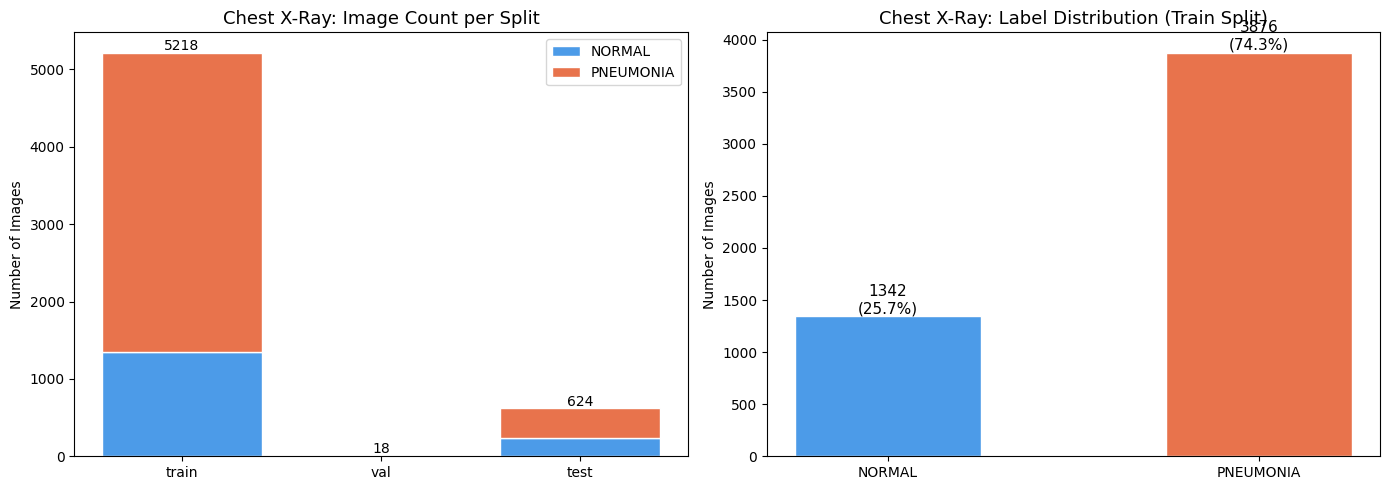

Train class ratio PNEUMONIA/NORMAL: 2.89


In [20]:
# Label distribution plot — stacked bar per split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: stacked bar chart per split ---
colors = {"NORMAL": "#4C9BE8", "PNEUMONIA": "#E8734C"}
bottoms = np.zeros(len(splits))
for label in labels:
    vals = [xray_counts[s][label] for s in splits]
    axes[0].bar(splits, vals, bottom=bottoms, label=label, color=colors[label], edgecolor="white")
    bottoms += np.array(vals)

axes[0].set_title("Chest X-Ray: Image Count per Split", fontsize=13)
axes[0].set_ylabel("Number of Images")
axes[0].legend()
for i, split in enumerate(splits):
    total = xray_df.filter(pl.col("split") == split)["Total"][0]
    axes[0].text(i, total + 30, str(total), ha="center", fontsize=10)

# --- Right: overall class imbalance (train only) ---
train_vals = [xray_counts["train"][l] for l in labels]
axes[1].bar(labels, train_vals, color=[colors[l] for l in labels], edgecolor="white", width=0.5)
axes[1].set_title("Chest X-Ray: Label Distribution (Train Split)", fontsize=13)
axes[1].set_ylabel("Number of Images")
for i, v in enumerate(train_vals):
    pct = v / sum(train_vals) * 100
    axes[1].text(i, v + 30, f"{v}\n({pct:.1f}%)", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("figures/xray_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Train class ratio PNEUMONIA/NORMAL:", round(xray_counts['train']['PNEUMONIA'] / xray_counts['train']['NORMAL'], 2))

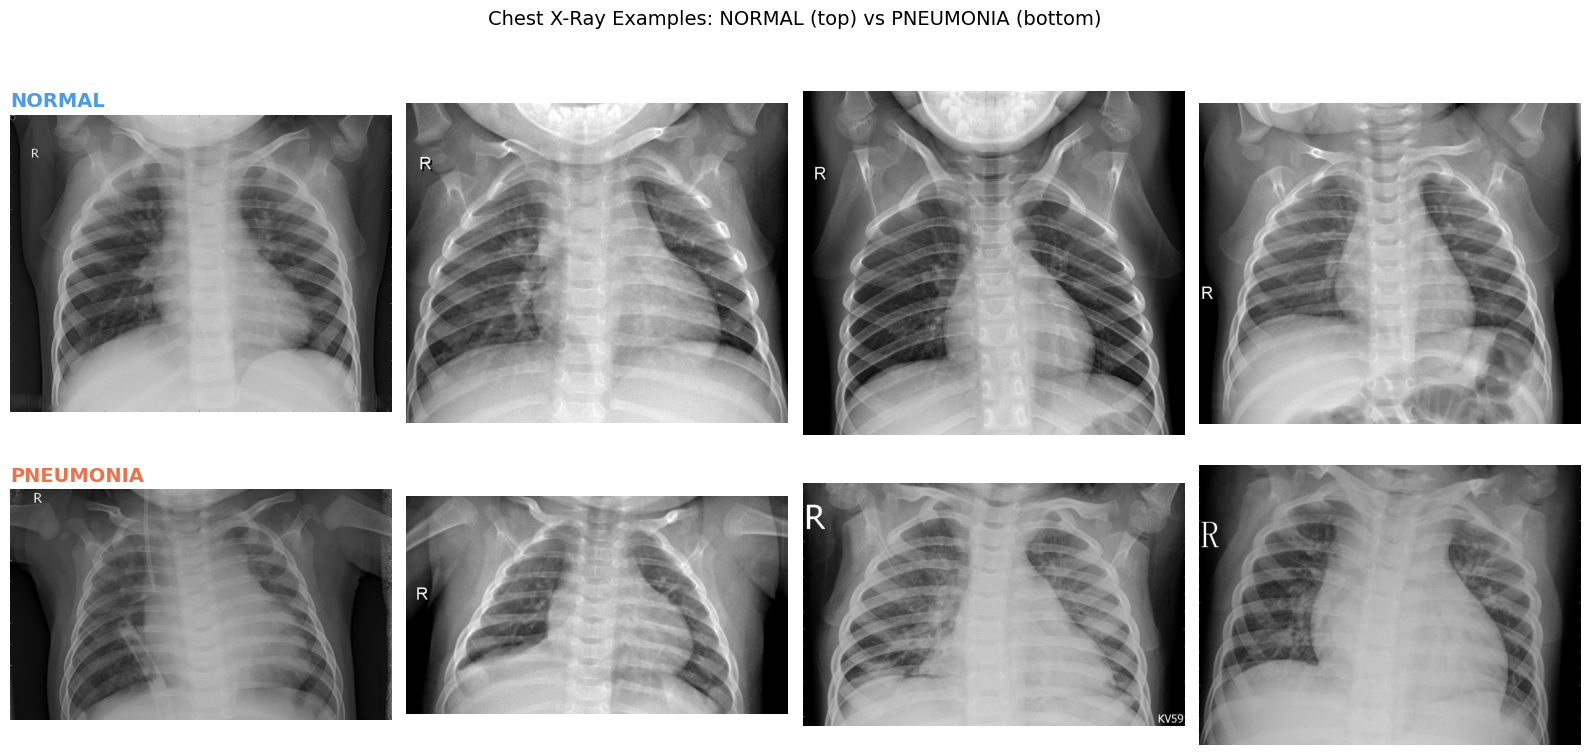

In [21]:
# Qualitative examples: 4 NORMAL and 4 PNEUMONIA from the training set
n_examples = 4
fig, axes = plt.subplots(2, n_examples, figsize=(16, 8))

for row, label in enumerate(labels):
    img_dir = os.path.join(XRAY_DIR, "train", label)
    img_files = random.sample(os.listdir(img_dir), n_examples)
    for col, fname in enumerate(img_files):
        img = Image.open(os.path.join(img_dir, fname)).convert("L")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(label, fontsize=14, fontweight="bold",
                                     color=colors[label], loc="left")

fig.suptitle("Chest X-Ray Examples: NORMAL (top) vs PNEUMONIA (bottom)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures/xray_examples.png", dpi=150, bbox_inches="tight")
plt.show()

## Q1.2 — Visual Differences Between Healthy and Disease Samples

**Visual differences:**

Yes, there are clear visual differences between the two classes:

- **NORMAL** X-rays show **dark, homogeneous lung fields** with clearly visible lung markings (bronchial and vascular structures) and sharp cardiac/diaphragmatic borders. The pleural spaces are clean.

- **PNEUMONIA** X-rays show **increased opacity (whitening)** in one or both lung fields, reflecting fluid, pus, or inflammatory infiltrate in the alveoli. Consolidations can appear as dense, patchy, or diffuse opacifications. In the mean image comparison above, the difference map (right panel) shows elevated pixel intensity in the lower/mid lung zones for PNEUMONIA, which corresponds to the typical distribution of consolidations.

- Overall image contrast and brightness also differ: pneumonia images tend to be brighter on average

## Q1.3 — Potential Source of Bias

We also notice that the training set is severely imbalanced (~74% PNEUMONIA, ~26% NORMAL, ratio ≈ 2.89:1). A model trained without correcting for this will be biased toward predicting PNEUMONIA more often, since this minimises overall loss. This inflates sensitivity (recall for PNEUMONIA) at the expense of specificity (recall for NORMAL), leading to an over-eager classifier that flags many healthy patients as sick. In a clinical deployment this corresponds to a high false-positive rate. On the one hand, in the medical context, having more false positives is better than having false negatives, on the other hand, every false positive causes unnecessary further testing and patient anxiety. 

## Q1.4 — Data Preprocessing

In [22]:
IMG_SIZE = 224
BATCH_SIZE = 32

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = ImageFolder(os.path.join(XRAY_DIR, "train"), transform=train_transforms)
val_dataset   = ImageFolder(os.path.join(XRAY_DIR, "val"),   transform=eval_transforms)
test_dataset  = ImageFolder(os.path.join(XRAY_DIR, "test"),  transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)}  |  Val: {len(val_dataset)}  |  Test: {len(test_dataset)}")
print(f"Classes: {train_dataset.class_to_idx}")

Train: 5216  |  Val: 16  |  Test: 624
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


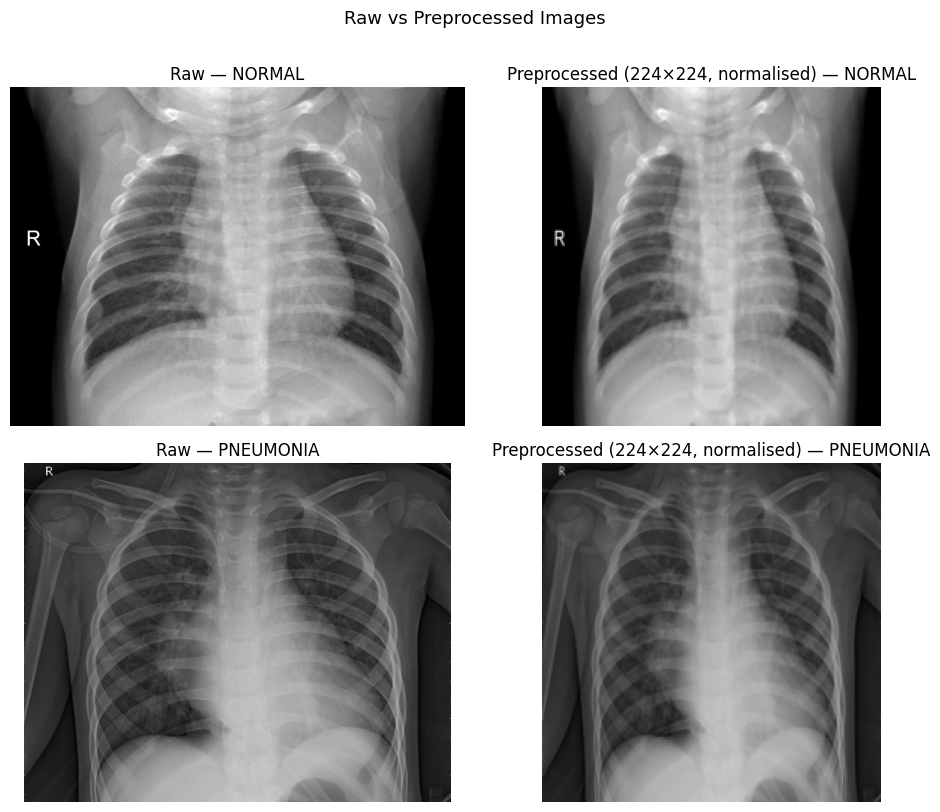

In [23]:
# Visualise one preprocessed sample per class alongside the raw original
inv_norm = transforms.Normalize(
    mean=[-m / s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1 / s for s in IMAGENET_STD],
)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for row, (label_name, _) in enumerate(train_dataset.class_to_idx.items()):
    img_dir = os.path.join(XRAY_DIR, "train", label_name)
    raw = Image.open(os.path.join(img_dir, random.choice(os.listdir(img_dir)))).convert("RGB")

    axes[row, 0].imshow(raw)
    axes[row, 0].set_title(f"Raw — {label_name}", fontsize=12)
    axes[row, 0].axis("off")

    tensor = eval_transforms(raw)
    display_img = inv_norm(tensor).permute(1, 2, 0).numpy().clip(0, 1)
    axes[row, 1].imshow(display_img)
    axes[row, 1].set_title(f"Preprocessed (224×224, normalised) — {label_name}", fontsize=12)
    axes[row, 1].axis("off")

plt.suptitle("Raw vs Preprocessed Images", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/xray_preprocessing.png", dpi=150, bbox_inches="tight")
plt.show()

**Preprocessing steps:**

1. **Resize to 224×224**: X-ray images vary in native resolution; a fixed size is required for batched training and for standard CNN architectures.

2. **Grayscale → 3-channel RGB**: images are natively single-channel; converting to RGB (by replicating the channel) allows pretrained ImageNet backbones to be used without architectural changes.

3. **Data augmentation (train only)**: random horizontal flipping and small rotations (±10°) increase effective dataset size and reduce overfitting. These are anatomically plausible for chest X-rays.

4. **Scale to [0, 1]**: pixel values are divided by 255.

5. **Normalise with ImageNet statistics**: subtracts the per-channel ImageNet mean and divides by the standard deviation (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), aligning the input distribution with what the pretrained backbone was trained on.

In [24]:
# Save preprocessed images for all splits as numpy arrays
# Uses eval_transforms (no augmentation) for reproducibility
save_dataset = ImageFolder(os.path.join(XRAY_DIR, "train"), transform=eval_transforms)
save_loader  = DataLoader(save_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

os.makedirs("data/preprocessed", exist_ok=True)

for name, loader in [("train", save_loader), ("val", val_loader), ("test", test_loader)]:
    all_imgs, all_labels = [], []
    for imgs, lbls in loader:
        all_imgs.append(imgs.numpy())
        all_labels.append(lbls.numpy())
    np.savez_compressed(
        f"data/preprocessed/{name}.npz",
        images=np.concatenate(all_imgs),
        labels=np.concatenate(all_labels),
    )
    n = sum(len(l) for l in all_labels)
    print(f"Saved {name}: {n} images → data/preprocessed/{name}.npz")

Saved train: 5216 images → data/preprocessed/train.npz
Saved val: 16 images → data/preprocessed/val.npz
Saved test: 624 images → data/preprocessed/test.npz


## Q2 — CNN Classifier
### Q2.1 — Model Design

In [25]:
DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                       else "cuda" if torch.cuda.is_available()
                       else "cpu")
print("Device:", DEVICE)

# ResNet-18 pretrained on ImageNet, final layer replaced for binary classification
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(DEVICE)

# Class weights to counteract the ~3:1 PNEUMONIA/NORMAL imbalance
targets = torch.tensor(train_dataset.targets)
class_counts = torch.bincount(targets).float()
class_weights = (class_counts.sum() / (2 * class_counts)).to(DEVICE)
print(f"Class weights — NORMAL: {class_weights[0]:.3f}, PNEUMONIA: {class_weights[1]:.3f}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Device: mps
Class weights — NORMAL: 1.945, PNEUMONIA: 0.673


In [26]:
NUM_EPOCHS = 10
best_val_acc = 0.0
train_losses, val_accs = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    # --- training ---
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_dataset)
    train_losses.append(train_loss)

    # --- validation ---
    model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            correct += (model(imgs).argmax(1) == labels).sum().item()
    val_acc = correct / len(val_dataset)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  loss: {train_loss:.4f}  val_acc: {val_acc:.4f}")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch 01/10  loss: 0.1269  val_acc: 0.8125
Epoch 02/10  loss: 0.0611  val_acc: 0.9375
Epoch 03/10  loss: 0.0574  val_acc: 0.9375
Epoch 04/10  loss: 0.0353  val_acc: 0.7500
Epoch 05/10  loss: 0.0404  val_acc: 1.0000
Epoch 06/10  loss: 0.0229  val_acc: 0.9375
Epoch 07/10  loss: 0.0317  val_acc: 1.0000
Epoch 08/10  loss: 0.0230  val_acc: 1.0000
Epoch 09/10  loss: 0.0188  val_acc: 1.0000
Epoch 10/10  loss: 0.0221  val_acc: 0.9375

Best val accuracy: 1.0000


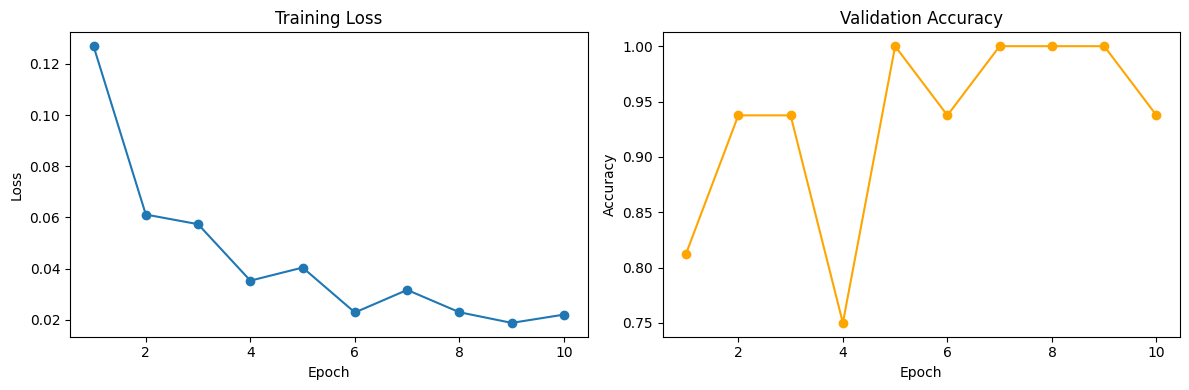

In [31]:
# Training curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, NUM_EPOCHS + 1), train_losses, marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(range(1, NUM_EPOCHS + 1), val_accs, marker="o", color="orange")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.savefig("figures/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### Q2.2 — Test Performance

In [32]:
# Load best checkpoint
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()

all_labels, all_preds, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

class_names = ["NORMAL", "PNEUMONIA"]
print("Test set performance")
print(f"  Accuracy  : {accuracy_score(all_labels, all_preds):.4f}")
print(f"  Precision : {precision_score(all_labels, all_preds):.4f}")
print(f"  Recall    : {recall_score(all_labels, all_preds):.4f}")
print(f"  F1        : {f1_score(all_labels, all_preds):.4f}")
print(f"  AUC-ROC   : {roc_auc_score(all_labels, all_probs):.4f}")

Test set performance
  Accuracy  : 0.8702
  Precision : 0.8381
  Recall    : 0.9821
  F1        : 0.9044
  AUC-ROC   : 0.9645


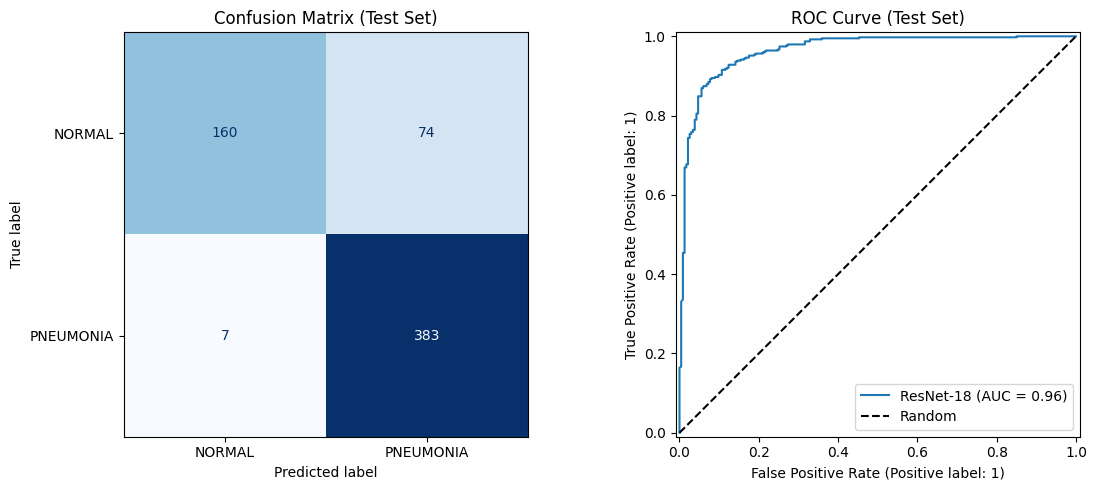

In [29]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Test Set)")

# ROC curve
RocCurveDisplay.from_predictions(all_labels, all_probs, ax=axes[1], name="ResNet-18")
axes[1].plot([0, 1], [0, 1], "k--", label="Random")
axes[1].set_title("ROC Curve (Test Set)")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/test_performance.png", dpi=150, bbox_inches="tight")
plt.show()

**Test set results (ResNet-18, 10 epochs, weighted loss):**

| Metric | Value |
|--------|-------|
| Accuracy | 0.870 |
| Precision | 0.838 |
| Recall | 0.982 |
| F1 | 0.904 |
| AUC-ROC | 0.965 |

Accuracy is not the primary metric here: the test set is imbalanced (390 PNEUMONIA vs. 234 NORMAL), so a trivial classifier that always predicts PNEUMONIA would already achieve 62.5% accuracy. The more meaningful metrics are **recall** and **AUC-ROC**. A recall of 0.982 means only ~7 out of 390 pneumonia cases are missed — the key clinical requirement. The AUC-ROC of 0.965 indicates excellent discrimination across all thresholds. The lower precision (0.838) reflects that the model flags roughly 1 in 3 healthy patients as sick, which is acceptable in a screening context where false positives lead only to a follow-up examination, whereas false negatives risk delayed treatment.

### Note: Threshold Optimisation

If recall at the default threshold (0.5) were insufficient for clinical requirements, one could adjust the decision threshold post-hoc without retraining. Lowering the threshold causes the model to classify more samples as PNEUMONIA, increasing recall at the cost of precision (more false positives). The optimal threshold can be found by sweeping values and selecting the one that maximises recall subject to a minimum precision constraint (e.g. precision ≥ 0.85).

In our case this is not necessary: recall is already 0.982 at the default threshold, meaning only ~7 out of 390 pneumonia cases are missed. The model is already well-suited to the clinical requirement of minimising false negatives.